In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
wav = np.array([lambda_mm[5] / 10])
wav

array([0.15])

In [4]:
# raise SystemExit("Stop here")

# Load in Data at the chosen band

In [5]:
bands = [4, 5, 6, 7]
wavelengths = [lambda_mm[band] for band in bands]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz"   
}



# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    filename = prefix + band_prefix[band] + file_names['1']
    d = np.load(filename)

    data[wav] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 3.7e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.7e+03%: above error tolerance
  warnings.warn(


# Single Plot

In [6]:
colour1 = alma_band_colors[4]
colour2 = alma_band_colors[6]
colour3 = 'dimgrey'
lw = 3
fs = 25

In [7]:
band = 7 

data_band = data[wavelengths[3]]

a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])

In [8]:
xmin = 0.5e-3
xmax = 5.7

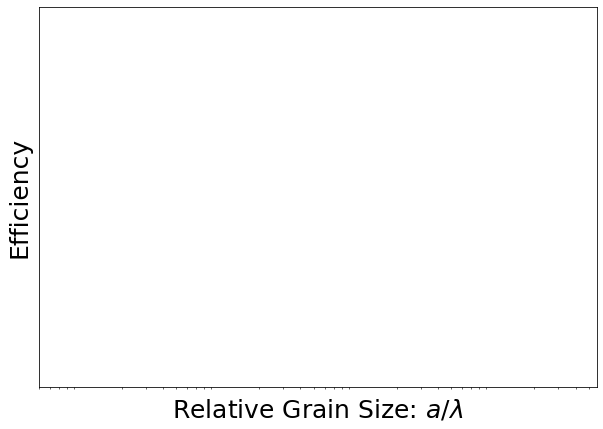

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


# ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
# ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

# ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
# ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step0.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

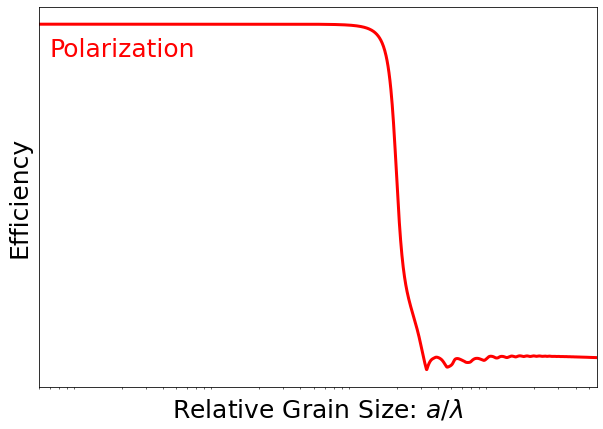

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xlim(xmin, xmax)
ax.set_xscale('log')

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

# ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
# ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step1.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DEFENCE/Pw/' + "PolarizationvsScattering_Step1.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

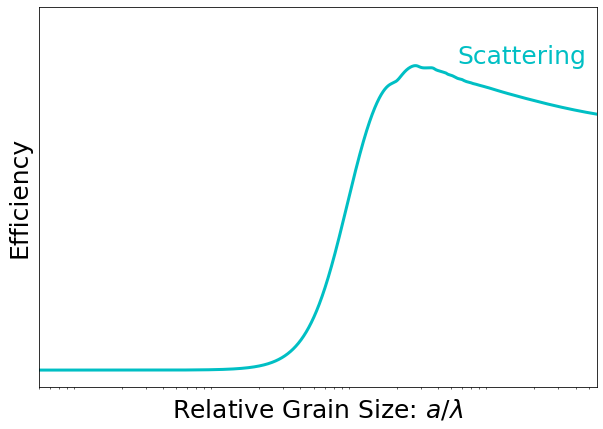

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.set_xticks([])


tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


# ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
# ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.85, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step2.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step2.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

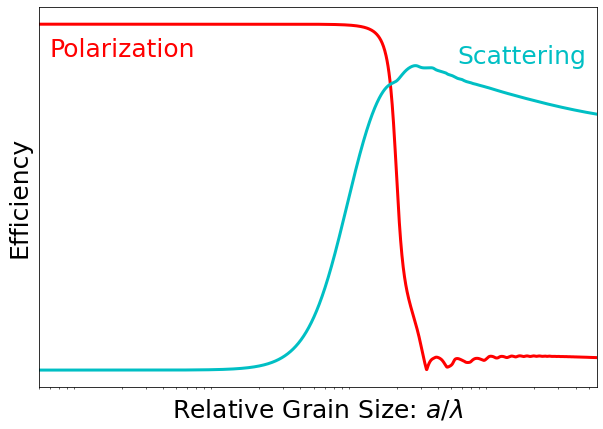

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.set_xticks([])


tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.85, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
# ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step3.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step3.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

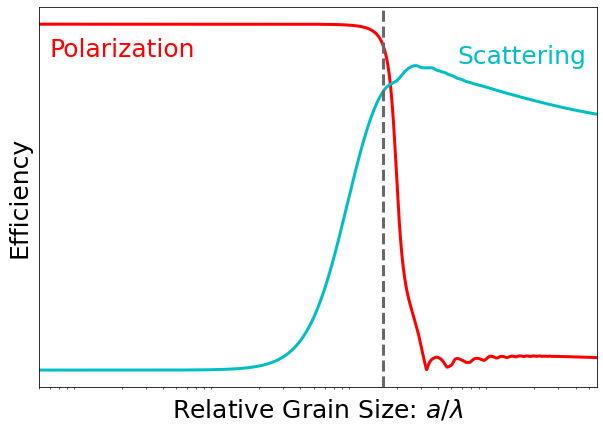

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.set_xticks([])

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.85, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

# ax.text(0.45, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step4.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Step4.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

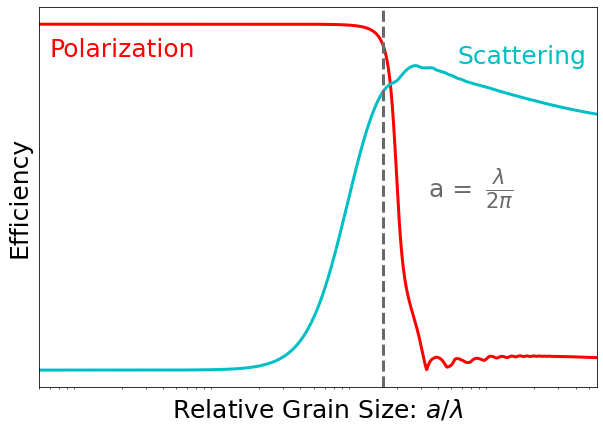

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.set_xticks([])

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.85, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

x = 0.7
y = 0.5
ax.text(x, y, r'a = ',transform=ax.transAxes, fontsize= fs, color = colour3)
ax.text(x + 0.1, y, r'$\frac{\lambda}{2\pi}$',transform=ax.transAxes, fontsize= fs + 5, color = colour3)
ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)


# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_ALL.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_ALL.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

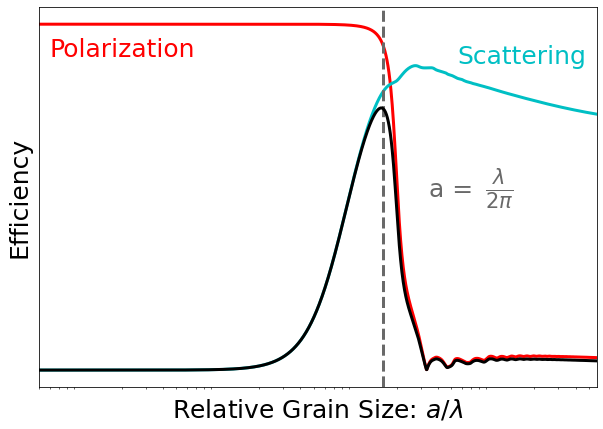

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
ax.set_ylabel('Efficiency', fontsize = fs)

ax.set_xscale('log')
ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.set_xticks([])

tol = 0.05
ax.set_ylim(0 - tol, 1 + tol)
ax.set_yticks([])
ax.set_xticks([])


#ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

ax.text(0.75, 0.85, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

x = 0.7
y = 0.5
ax.text(x, y, r'a = ',transform=ax.transAxes, fontsize= fs, color = colour3)
ax.text(x + 0.1, y, r'$\frac{\lambda}{2\pi}$',transform=ax.transAxes, fontsize= fs + 5, color = colour3)
ax.axvline(1/ (2*np.pi), ls = '--', color = colour3, lw = lw)



ax.plot(a_lam_grid, data_band['P_omega_eff'], color = 'black', lw = lw )


# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_ALL_Pw.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_ALL_Pw.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

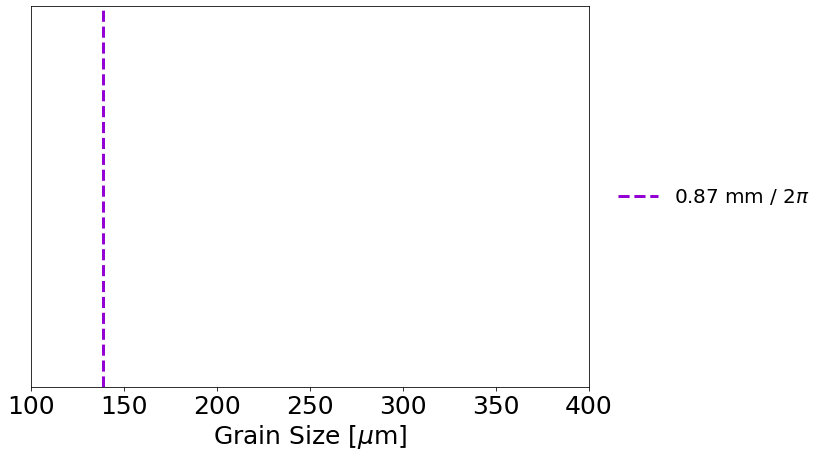

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size [$\mu$m]', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)



ax.set_xlim(100, 400)

# Add more vertical lines
i = 3
    
lam_micron = mm_to_micron(wavelengths[i])

val = (lam_micron) / (2 * np.pi)

print('')

#ax.axvline(val, ls = '--', lw = lw, color = colours[i], label =f'{wavelengths[i]} mm / 2$\pi$')
ax.axvline(val, ls = '--', lw = lw, color = colours[3], label =f'{wavelengths[3]} mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_Just7.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_Just7.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

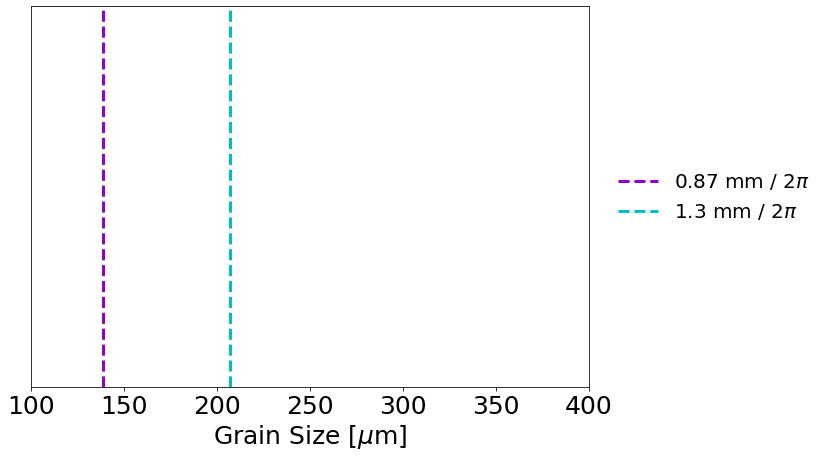

In [17]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size [$\mu$m]', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)




ax.set_xlim(100, 400)

# Add more vertical lines
for i in range(2):
    
    lam_micron = mm_to_micron(wavelengths[3-i])
    
    val = (lam_micron) / (2 * np.pi)
    
    print('')
    
    ax.axvline(val, ls = '--', lw = lw, color = colours[3-i], label =f'{wavelengths[3-i]} mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_2.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_2.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

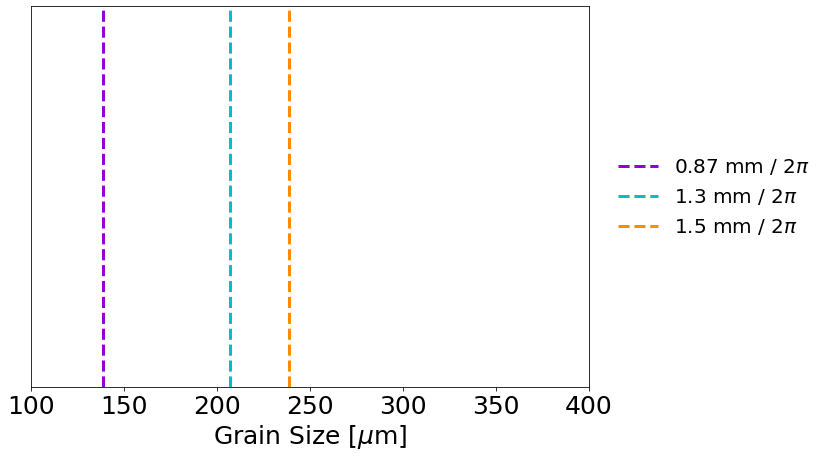

In [18]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size [$\mu$m]', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)




ax.set_xlim(100, 400)

# Add more vertical lines
for i in range(3):
    
    lam_micron = mm_to_micron(wavelengths[3-i])
    
    val = (lam_micron) / (2 * np.pi)
    
    print('')
    
    ax.axvline(val, ls = '--', lw = lw, color = colours[3-i], label =f'{wavelengths[3-i]} mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_3.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')


# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_3.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

lam_micron: 870.0, val = 138.46480048994894

lam_micron: 1300.0, val = 206.90142601946394

lam_micron: 1500.0, val = 238.73241463784302

lam_micron: 2100.0, val = 334.2253804929802



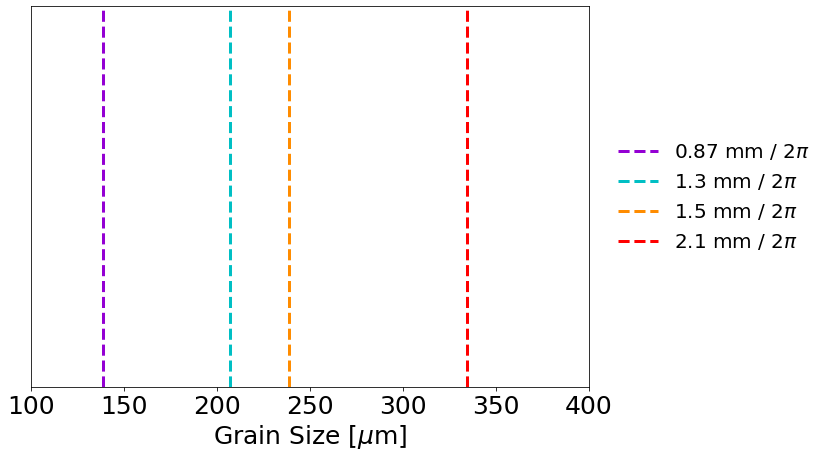

In [19]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Grain Size [$\mu$m]', fontsize = fs)
#ax.set_ylabel('Efficiency', fontsize = fs)

# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)




ax.set_xlim(100, 400)

# Add more vertical lines
for i in range(4):
    
    lam_micron = mm_to_micron(wavelengths[3-i])
    
    val = (lam_micron) / (2 * np.pi)
    print(f'lam_micron: {lam_micron}, val = {val}')
    
    print('')
    
    ax.axvline(val, ls = '--', lw = lw, color = colours[3-i], label =f'{wavelengths[3-i]} mm / 2$\pi$')
    
ax.legend(
    frameon=False,
    fontsize=20,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_All.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_All.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')

In [28]:
wavelengths

[2.1, 1.5, 1.3, 0.87]

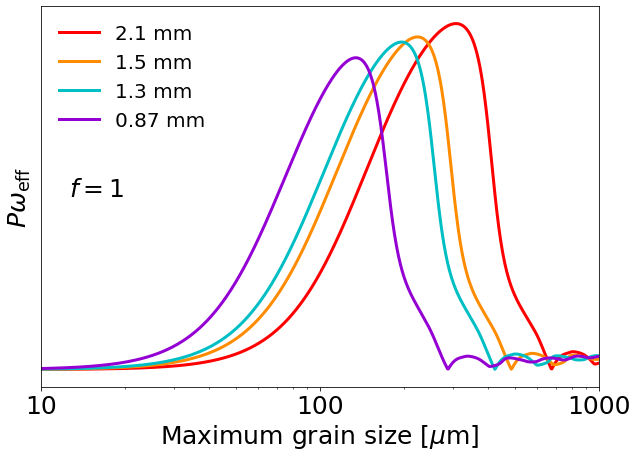

In [41]:
# Pick your wavelength
# band = 7

# data_band = data[wavelengths[3]]

# band_lam = mm_to_cm(wavelengths[3])

# a_lam_grid = data_band['a'] / band_lam


fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize = fs)
ax.set_ylabel(rf'$P\omega_{{\mathrm{{eff}}}}$', fontsize = fs)
   
# ax.set_xscale('log')
# ax.set_xlim(1e-3, 1e2)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=fs)

# labels = ['0.87 mm' , '1.3 mm', '1.5 mm', '2.1 mm']

labels = ['2.1 mm','1.5 mm', '1.3 mm', '0.87 mm']

# band = 7 

# data_band = data[wavelengths[3]]

# a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[3])


# ax.set_xlim(10, 1000)
# ax.set_ylim(0, 1.25)

ax.set_xscale('log')

bb = [7, 6, 5, 4]
# Add more vertical lines
for i, band in enumerate(bb):
    
    #print()
    
    band_data = data[wavelengths[i]]
    
    lam_micron = mm_to_micron(wavelengths[i])
    
    val = (lam_micron) / (2 * np.pi)
    
    #print(rf'band = {band}, lam um = {lam_micron}, val = {val}')
    
    
    
    
    #ax.axvline(val, ls = '--', lw = lw, color = colours[3-i], label =f'{wavelengths[3-i]} mm / 2$\pi$', alpha = 0.25)
    
    
    a_micron = cm_to_micron(band_data['a'])
    ax.plot(a_micron, band_data['P_omega_eff'], color = colours[i], lw = lw, alpha = 1, label = labels[i])
    
    #print(f'min: {min(a_micron)},  max: {max(a_micron)}')
    
    #print(' ')
    
# add_min_major_ticks(ax, top = False) 
# ax.axvline(0.1, lw = lw, color = 'black', label ='Scattering Polarization', alpha = 0.75)
# ax.axvline(0.1, lw = lw, color = 'white', label ='Efficiency (P$\omega_{eff}$)', alpha = 0.75)

ax.set_xlim(10, 1000)
nums = [10, 100, 1000]
ax.set_xticks(nums)
ax.set_xticklabels(nums)

ax.legend(
    frameon=False,
    fontsize=20,
    loc='upper left',
#     bbox_to_anchor=(1.02, 0.5)
)

# Also want to plot Band 5 data 
# plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering_Lines_All_Curves.jpeg", 
#             dpi=1000, 
#             bbox_inches='tight')


ax.text(0.05, 0.5, rf'$f = 1$',transform=ax.transAxes,fontsize= fs)


plt.savefig(image_folder_path + '/SLIDESHOW/DEFENCE/Pw/' + "Pw_curves.jpeg", 
            dpi=1000, 
            bbox_inches='tight')

## Grid

In [ ]:
# fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey = True)

# for i in range(4):

#     data_band = data[wavelengths[i]]

#     a_lam_grid = data_band['a'] / mm_to_cm(wavelengths[i])
    
#     print(f'wavelength = {wavelengths[i]} and peak is at: {wavelengths[i]/(2*np.pi)}')

#     ax = axes[i]


#     ax.set_xscale('log')
#     ax.set_xlim(1e-3, 1e2)
#     #ax.set_xticks([])
#     ax.set_yticks([])
#     #ax.tick_params(axis='x', labelbottom=False)


#     #ax.text(0.75, 0.90, rf'$\lambda = {lam_mm}$ mm',transform=ax.transAxes,fontsize= fs*0.75)


#     ax.text(0.02, 0.87, rf'Polarization', transform=ax.transAxes,fontsize= fs,color = colour1)
#     ax.plot(a_lam_grid, data_band['P'], color = colour1, lw = lw )

#     ax.text(0.75, 0.75, rf'Scattering',transform=ax.transAxes, fontsize= fs, color = colour2)
#     ax.plot(a_lam_grid, data_band['omega_eff'] , colour2, lw = lw )

#     ax.text(0.4, 0.9, rf'a = $\lambda/2\pi$',transform=ax.transAxes, fontsize= fs, color = colour3)
#     ax.axvline(1/ (2*np.pi), label = 'a = $\lambda/2\pi$', ls = '--', color = colour3, lw = lw)


# axes[0].set_ylabel('Efficiency', fontsize = fs)
# fig.supxlabel('Relative Grain Size: $a/\lambda$', fontsize = fs)
    
# # plt.savefig(image_folder_path + '/SLIDESHOW/DustModels/' + "PolarizationvsScattering.jpeg", 
# #             dpi=1000, 
# #             bbox_inches='tight')